# 04 — Phase Plane Analysis (Interactive)

**Goal of this notebook.** Notebook 03 showed *that* retuning $(a, b, \tau_w, v_{reset})$ produces wildly different firing patterns. This notebook shows **why**, geometrically, using the $(v, w)$ **phase plane**.

At any instant, an AdEx neuron's full state is the point $(v, w)$. Two curves organize everything that can happen:

- the **v-nullcline** ($dv/dt = 0$): $w = -g_L(v-E_L) + g_L\Delta_T e^{(v-v_T)/\Delta_T} + I$
- the **w-nullcline** ($dw/dt = 0$): $w = a(v - E_L)$ — a straight line through $(E_L, 0)$ with slope $a$

Wherever these two curves **cross**, both derivatives are zero simultaneously — a **fixed point**: if the trajectory ever sat exactly there, it would stay forever. Everywhere else, the trajectory flows; its direction at any $(v,w)$ is given by the two derivative equations. Whether a neuron rests quietly or fires spikes for a given current turns out to be a question of **how many fixed points exist, and where** — not a separate, arbitrary "threshold" rule bolted on top.

This notebook ends with a live `ipywidgets` explorer: drag $a$, $b$, $\tau_w$, $v_{reset}$, and the input current $I$, and watch the nullclines — and the resulting firing pattern — shift in real time. **If you're viewing a static export of this notebook (e.g. on GitHub), the sliders won't respond to clicks** — open it with a running kernel (`jupyter notebook notebooks/04_Phase_Plane_Analysis.ipynb`) to interact live. The cell output below was captured at the sliders' default position.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from ipywidgets import interact, FloatSlider, Layout

from src.neuron_models import AdExNeuron

%matplotlib inline

mpl.rcParams.update({
    "figure.dpi": 105,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

COLOR_V_NULL = "#2b6cb0"
COLOR_W_NULL = "#dd6b20"
COLOR_TRAJ = "#1a202c"
COLOR_FP = "#e53e3e"

# Fixed baseline biophysical parameters for the whole notebook — only the
# adaptation/reset parameters and the input current will be varied.
BASE = dict(C_m=200.0, g_L=10.0, E_L=-70.0, v_T=-50.0, delta_T=2.0, v_peak=0.0, dt=0.1)
V_RANGE = np.linspace(-90, -35, 600)


## 1. Two helper functions we'll reuse throughout

`find_fixed_points` scans the nullclines for sign changes in their difference (a simple, robust root-finder for this purpose). `classify_regime` turns a spike train into one of the qualitative labels from Notebook 03, purely from its ISI pattern — not scientifically rigorous, but a handy live readout for the explorer below.

In [2]:
def find_fixed_points(neuron, v_range, I):
    w_v, w_w = neuron.nullclines(v_range, I=I)
    diff = w_v - w_w
    sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]
    fps = []
    for idx in sign_changes:
        v0, v1 = v_range[idx], v_range[idx + 1]
        d0, d1 = diff[idx], diff[idx + 1]
        v_fp = v0 - d0 * (v1 - v0) / (d1 - d0)
        w_fp = neuron.a * (v_fp - neuron.E_L)
        fps.append((v_fp, w_fp))
    return fps


def classify_regime(spike_times):
    if len(spike_times) < 2:
        return "Quiescent (0-1 spikes)"
    isis = np.diff(spike_times)
    if len(isis) < 2:
        return "Onset spike(s) only"
    cv = np.std(isis) / np.mean(isis)
    increasing = np.all(np.diff(isis) >= -0.05 * np.mean(isis))
    bursty = (isis.max() / isis.min() > 3.0) and cv > 0.4
    if bursty:
        return "Bursting"
    elif increasing and cv > 0.1:
        return "Adapting"
    elif cv < 0.15:
        return "Tonic spiking"
    else:
        return "Irregular"


## 2. Why spiking happens: the fixed point disappears

Fix every adaptation parameter and sweep only the input current $I$. Watch what happens to the fixed points.

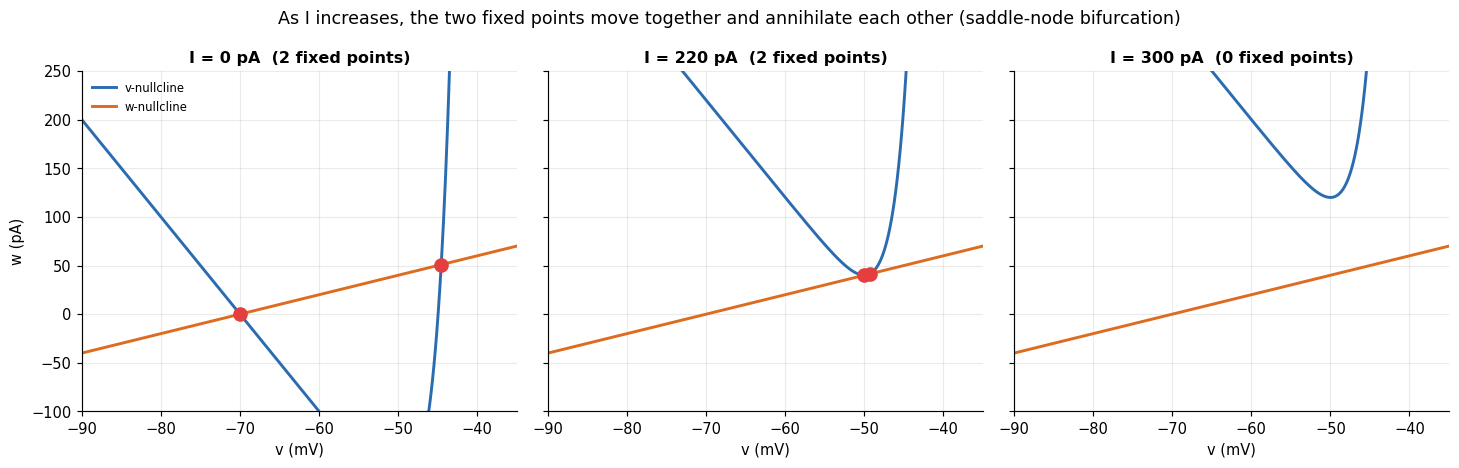

In [3]:
neuron = AdExNeuron(a=2.0, tau_w=100.0, b=60.0, v_reset=-58.0, **BASE)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, I in zip(axes, [0.0, 220.0, 300.0]):
    w_v_null, w_w_null = neuron.nullclines(V_RANGE, I=I)
    fps = find_fixed_points(neuron, V_RANGE, I)

    ax.plot(V_RANGE, w_v_null, color=COLOR_V_NULL, lw=2, label="v-nullcline")
    ax.plot(V_RANGE, w_w_null, color=COLOR_W_NULL, lw=2, label="w-nullcline")
    for v_fp, w_fp in fps:
        ax.plot(v_fp, w_fp, "o", color=COLOR_FP, ms=9, zorder=5)
    ax.set_xlim(-90, -35); ax.set_ylim(-100, 250)
    ax.set_xlabel("v (mV)")
    ax.set_title(f"I = {I:.0f} pA  ({len(fps)} fixed point{'s' if len(fps) != 1 else ''})")
axes[0].set_ylabel("w (pA)")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("As I increases, the two fixed points move together and annihilate each other (saddle-node bifurcation)")
plt.tight_layout()
plt.show()


At $I=0$: two fixed points — a stable one near $E_L$ (where the neuron rests) and an unstable one further right (a genuine, geometric "threshold": start to its right and the trajectory escapes toward a spike instead of settling). As $I$ grows, the v-nullcline shifts upward and the two fixed points slide toward each other. Somewhere between 220 and 230 pA here, they **collide and vanish** — with nothing left to rest at, the trajectory has no choice but to cycle around and around the phase plane indefinitely: repetitive spiking. This is *why* a rheobase exists, and it's the same mechanism EIF (Notebook 02) and AdEx both rely on — AdEx just has a second dimension for that nullcline geometry to play out in, which is exactly what allows adaptation and bursting on top of it.

## 3. Now make it interactive

Drag the sliders below. In particular, try:
- **Increasing $b$** with $a$ near zero: the spike-triggered jump in $w$ grows, dragging the trajectory further from the (now often absent) fixed point after every spike — ISIs lengthen. *Adaptation.*
- **Making $a$ negative** together with a high $v_{reset}$ (close to $v_T$): the trajectory can periodically swing back close enough to a transient fixed point to pause, then escape again. *Bursting.*
- **Sweeping $I$ up from 0**: watch the two fixed points in the left panel slide together and disappear, exactly as above — and watch the voltage trace switch from flat rest to repetitive spiking at almost the same current where that happens.

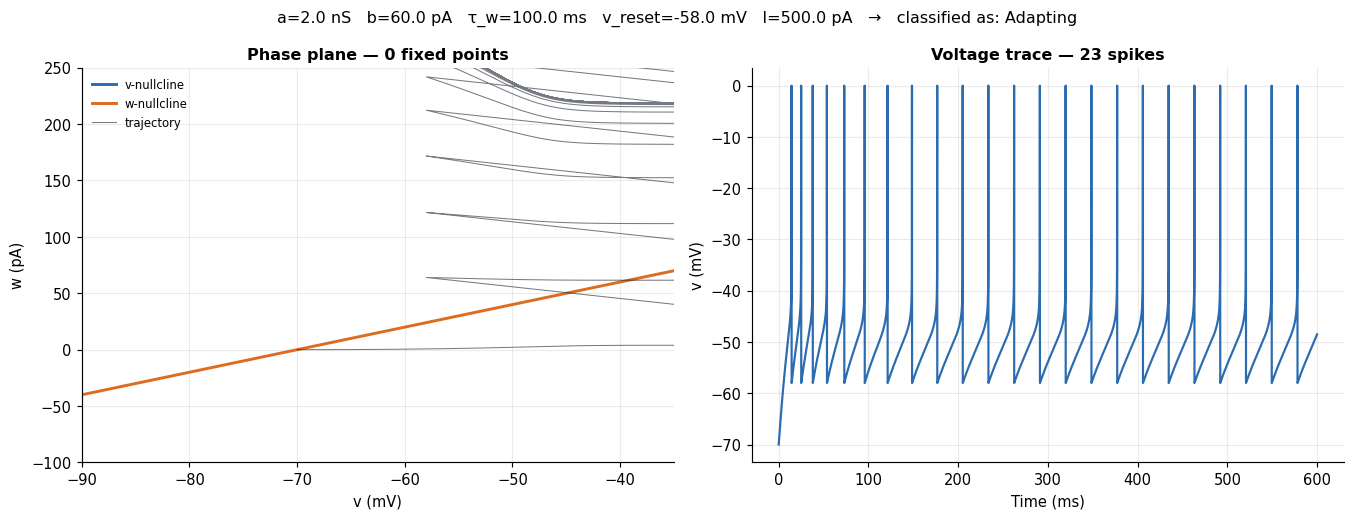

In [4]:
def explore_phase_plane(a=2.0, b=60.0, tau_w=100.0, v_reset=-58.0, I=500.0):
    neuron = AdExNeuron(a=a, b=b, tau_w=tau_w, v_reset=v_reset, **BASE)
    res = neuron.simulate(I_ext=I, T=600.0)
    fps = find_fixed_points(neuron, V_RANGE, I)
    w_v_null, w_w_null = neuron.nullclines(V_RANGE, I=I)
    regime = classify_regime(res["spike_times"])

    fig, (ax_phase, ax_trace) = plt.subplots(1, 2, figsize=(13, 5))

    ax_phase.plot(V_RANGE, w_v_null, color=COLOR_V_NULL, lw=2, label="v-nullcline")
    ax_phase.plot(V_RANGE, w_w_null, color=COLOR_W_NULL, lw=2, label="w-nullcline")
    ax_phase.plot(res["v"], res["w"], color=COLOR_TRAJ, lw=0.7, alpha=0.6, label="trajectory")
    for v_fp, w_fp in fps:
        ax_phase.plot(v_fp, w_fp, "o", color=COLOR_FP, ms=9, zorder=5)
    ax_phase.set_xlim(-90, -35); ax_phase.set_ylim(-100, 250)
    ax_phase.set_xlabel("v (mV)"); ax_phase.set_ylabel("w (pA)")
    ax_phase.set_title(f"Phase plane — {len(fps)} fixed point{'s' if len(fps) != 1 else ''}")
    ax_phase.legend(fontsize=8, loc="upper left")

    ax_trace.plot(res["t"], res["v"], color=COLOR_V_NULL)
    ax_trace.set_xlabel("Time (ms)"); ax_trace.set_ylabel("v (mV)")
    ax_trace.set_title(f"Voltage trace — {len(res['spike_times'])} spikes")

    fig.suptitle(f"a={a} nS   b={b} pA   \u03c4_w={tau_w} ms   v_reset={v_reset} mV   I={I} pA"
                 f"   \u2192   classified as: {regime}", fontsize=11)
    plt.tight_layout()
    plt.show()


# A plain, non-interactive call first, so this always renders as a normal
# static image (e.g. when viewing this notebook on GitHub, which does not
# execute the live ipywidgets below) — the *default* slider position:
explore_phase_plane()


### Live version

The cell below wraps the exact same function in `ipywidgets.interact`, adding the sliders. This is what you can actually drag — but again, only with a running kernel.

In [5]:
style = {"description_width": "110px"}
layout = Layout(width="380px")

interact(
    explore_phase_plane,
    a=FloatSlider(value=2.0, min=-10.0, max=10.0, step=0.5, description="a (nS)",
                  style=style, layout=layout, continuous_update=False),
    b=FloatSlider(value=60.0, min=0.0, max=200.0, step=5.0, description="b (pA)",
                  style=style, layout=layout, continuous_update=False),
    tau_w=FloatSlider(value=100.0, min=20.0, max=300.0, step=10.0, description="tau_w (ms)",
                       style=style, layout=layout, continuous_update=False),
    v_reset=FloatSlider(value=-58.0, min=-70.0, max=-40.0, step=2.0, description="v_reset (mV)",
                         style=style, layout=layout, continuous_update=False),
    I=FloatSlider(value=500.0, min=0.0, max=800.0, step=25.0, description="I (pA)",
                  style=style, layout=layout, continuous_update=False),
);


interactive(children=(FloatSlider(value=2.0, continuous_update=False, description='a (nS)', layout=Layout(widt…

## 4. Quick reference: the regimes from Notebook 03, as slider settings

Try dialing in each of these by hand in the widget above and watch both panels update:

| Regime | a (nS) | b (pA) | tau_w (ms) | v_reset (mV) |
|---|---|---|---|---|
| Tonic spiking | 0 | 0 | 100 | -58 |
| Adapting | 0 | 60 | 200 | -58 |
| Initial burst | 0 | 120 | 50 | -46 |
| Regular bursting | -5 | 100 | 100 | -46 |

## Summary

- Spiking in AdEx (and, in a simpler one-dimensional form, in EIF) corresponds to the **disappearance of a stable fixed point** in the phase plane as input current increases — not an arbitrary rule, but a geometric consequence of where the nullclines sit.
- The $w$-nullcline's slope ($a$) and the reset location ($v_{reset}$ relative to the nullclines) determine whether the trajectory settles into a small, regular limit cycle (tonic spiking), a slowly-drifting one (adaptation), or a cycle that repeatedly grazes a "near-fixed-point" region and pauses (bursting).
- All of Notebook 03's qualitatively different firing patterns are different regions of the *same* four-parameter space — which is exactly what the interactive explorer above lets you feel out directly, rather than just being told about.

**Next:** [05 — Balanced Recurrent Network](05_Balanced_Recurrent_Network.ipynb) leaves single-neuron dynamics behind and scales up to 1000 sparsely-connected LIF neurons, to see what *network-level* structure — rather than any single neuron's nonlinearity — can produce.
